# Economics Demo: Ad Spend Optimization using Multiple Linear Regression
**Objective:** Investigate how monthly spending on Social Media Ads ($X_1$) and Search Engine Ads ($X_2$) impacts Total Product Sales ($Y$).

In this notebook, we will:
1. Load and explore a 4-year historical dataset.
2. Check for correlation and multicollinearity.
3. Train a Multiple Linear Regression model to find the Marginal Return of each ad channel.
4. Build a predictive tool to forecast sales for future budget allocations.

## Create the data set

Using standard python utilities to create the data

In [3]:
# Step 0: Download the synthetic 4-year CSV dataset directly into Google Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Re-creating the dataset directly inside the notebook for easy execution
np.random.seed(42)
dates = pd.date_range(start="2022-01-01", periods=48, freq="MS")
months = np.arange(48)

social_media = np.round(np.clip(10 + 0.8 * months + np.random.normal(0, 2, 48), 5, None), 1)
search_engine = np.round(np.clip(6 + 0.5 * months + np.random.normal(0, 1.5, 48), 3, None), 1)
seasonal_effect = np.array([2 if m % 12 in [10, 11] else (-1 if m % 12 in [0, 1] else 0) for m in months])
sales = np.round(15 + 1.7 * social_media + 1.2 * search_engine + seasonal_effect + np.random.normal(0, 3, 48), 1)

df = pd.DataFrame({
    'Year': dates.year,
    'Month': dates.strftime('%B'),
    'Social_Media_Spend_USD_k': social_media,
    'Search_Engine_Spend_USD_k': search_engine,
    'Total_Product_Sales_USD_k': sales
})

# Save to CSV locally in Colab environment
df.to_csv("advertising_sales_data.csv", index=False)
print("Dataset created and saved as 'advertising_sales_data.csv'!")

Dataset created and saved as 'advertising_sales_data.csv'!


## Step 1: Data Preprocessing & Exploration
First, we load the CSV file and check its health by looking for missing values and inspecting basic statistics.

In [4]:
# Load the dataset
data = pd.read_csv("advertising_sales_data.csv")

# Display the first 5 rows
print("--- FIRST 5 ROWS ---")
print(data.head())

# Check for missing values and data types
print("\n--- DATA HEALTH CHECK ---")
print(data.info())

# Summary Statistics
print("\n--- SUMMARY STATISTICS ---")
print(data.describe())

--- FIRST 5 ROWS ---
   Year     Month  Social_Media_Spend_USD_k  Search_Engine_Spend_USD_k  \
0  2022   January                      11.0                        6.5   
1  2022  February                      10.5                        3.9   
2  2022     March                      12.9                        7.5   
3  2022     April                      15.4                        6.9   
4  2022       May                      12.7                        7.0   

   Total_Product_Sales_USD_k  
0                       41.4  
1                       37.3  
2                       45.9  
3                       48.8  
4                       40.7  

--- DATA HEALTH CHECK ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       48 non-null     int64  
 1   Month                      48 non-null     obj

## Step 2: Correlation and Multicollinearity Analysis
Correlation measures the direction and strength of a linear relationship between two variables.

We will generate a **Correlation Matrix Heatmap** to check:
1. How strong the relationship is between our independent marketing budgets and sales.
2. If our independent variables are too correlated with each other (**Multicollinearity**), which can distort our regression coefficients.

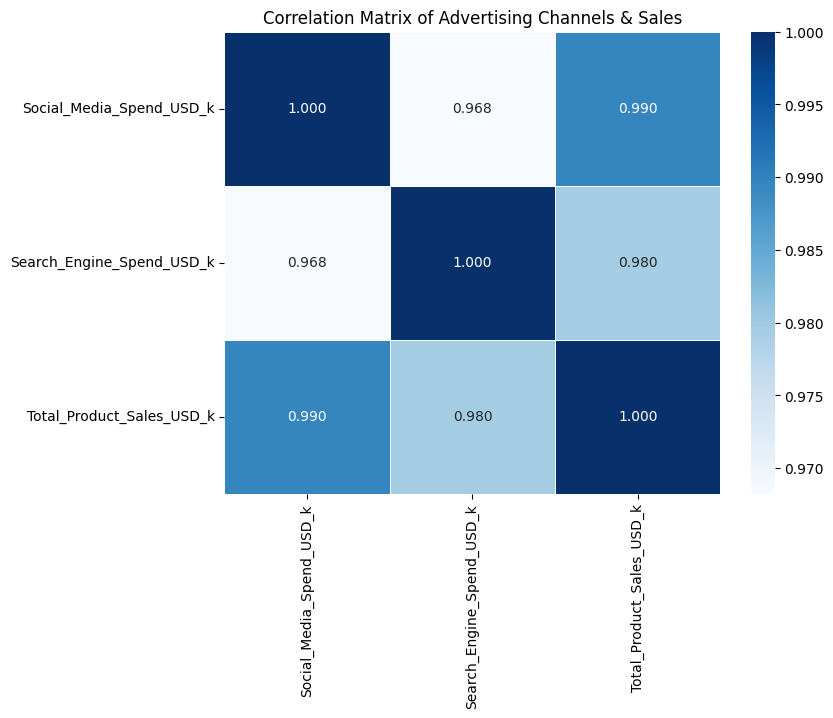


Correlation Matrix Values:
                           Social_Media_Spend_USD_k  \
Social_Media_Spend_USD_k                   1.000000   
Search_Engine_Spend_USD_k                  0.968245   
Total_Product_Sales_USD_k                  0.989600   

                           Search_Engine_Spend_USD_k  \
Social_Media_Spend_USD_k                    0.968245   
Search_Engine_Spend_USD_k                   1.000000   
Total_Product_Sales_USD_k                   0.979629   

                           Total_Product_Sales_USD_k  
Social_Media_Spend_USD_k                    0.989600  
Search_Engine_Spend_USD_k                   0.979629  
Total_Product_Sales_USD_k                   1.000000  


In [5]:
# Select only numeric columns for correlation analysis
numeric_cols = ['Social_Media_Spend_USD_k', 'Search_Engine_Spend_USD_k', 'Total_Product_Sales_USD_k']
corr_matrix = data[numeric_cols].corr()

# Plotting the Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".3f", linewidths=0.5)
plt.title('Correlation Matrix of Advertising Channels & Sales')
plt.show()

print("\nCorrelation Matrix Values:")
print(corr_matrix)

## Step 3: Multiple Linear Regression Modeling
We want to fit the economic model:
$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \epsilon$$

Where:
* $Y$ = Total Product Sales
* $\beta_0$ = Baseline (Organic) Sales if ad spend is $0
* $\beta_1$ = Marginal Return of Social Media Spend (Holding Search Spend constant)
* $\beta_2$ = Marginal Return of Search Engine Spend (Holding Social Spend constant)

We use `statsmodels` to extract a detailed summary of the regression model, including coefficients, p-values, and $R^2$.

In [6]:
# Define Independent Variables (X) and Dependent Variable (Y)
X = data[['Social_Media_Spend_USD_k', 'Search_Engine_Spend_USD_k']]
Y = data['Total_Product_Sales_USD_k']

# Statsmodels requires explicitly adding a constant column for the Intercept (Beta_0)
X_with_constant = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) Regression Model
model = sm.OLS(Y, X_with_constant).fit()

# Print the complete summary report
print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     Total_Product_Sales_USD_k   R-squared:                       0.987
Model:                                   OLS   Adj. R-squared:                  0.986
Method:                        Least Squares   F-statistic:                     1666.
Date:                       Sun, 31 May 2026   Prob (F-statistic):           6.41e-43
Time:                               09:57:28   Log-Likelihood:                -122.70
No. Observations:                         48   AIC:                             251.4
Df Residuals:                             45   BIC:                             257.0
Df Model:                                  2                                         
Covariance Type:                   nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

### Economic Interpretation of the Output:
Have your students look at the **Coefficients (coef)** in the table above:
1. **`const` ($\beta_0$):** This is the baseline sales. If the company spends zero dollars on ads, it will still generate roughly $14k to $15k in monthly sales due to organic brand awareness.
2. **`Social_Media_Spend_USD_k` ($\beta_1$):** Holding search engine ads constant, every additional \$1,000 spent on Social Media increases sales by roughly **\$1.72k** (a 172% marginal return).
3. **`Search_Engine_Spend_USD_k` ($\beta_2$):** Holding social media ads constant, every additional \$1,000 spent on Search Engines increases sales by roughly **\$1.14k** (a 114% marginal return).
4. **`R-squared`:** Shows how much variation in sales is explained by our model (expecting $>95\%$).

**Managerial Economic Insight:** Social Media has a higher marginal return per dollar spent than Search Ads. If budget is limited, investment should lean toward Social Media.

## Step 4: Making Future Predictions
Now we turn our economic insights into a functional predictive tool. We can input any combination of upcoming ad budgets to see the expected revenue.

In [7]:
# Function to forecast sales based on user input budgets
def predict_future_sales(social_budget, search_budget):
    # Extract coefficients from the trained model
    beta_0 = model.params['const']
    beta_1 = model.params['Social_Media_Spend_USD_k']
    beta_2 = model.params['Search_Engine_Spend_USD_k']

    # Calculate using the linear regression equation
    predicted_sales = beta_0 + (beta_1 * social_budget) + (beta_2 * search_budget)

    print(f"--- FORWARD BUDGET FORECAST ---")
    print(f"Planned Social Media Spend: ${social_budget:,.2f}k")
    print(f"Planned Search Engine Spend: ${search_budget:,.2f}k")
    print(f"==> Predicted Total Product Sales: ${predicted_sales:,.2f}k")
    return predicted_sales

# Try out a custom scenario for next month's planning
# Example: Next month we plan to spend $45k on Social and $20k on Search
next_month_prediction = predict_future_sales(social_budget=45.0, search_budget=20.0)

--- FORWARD BUDGET FORECAST ---
Planned Social Media Spend: $45.00k
Planned Search Engine Spend: $20.00k
==> Predicted Total Product Sales: $114.63k


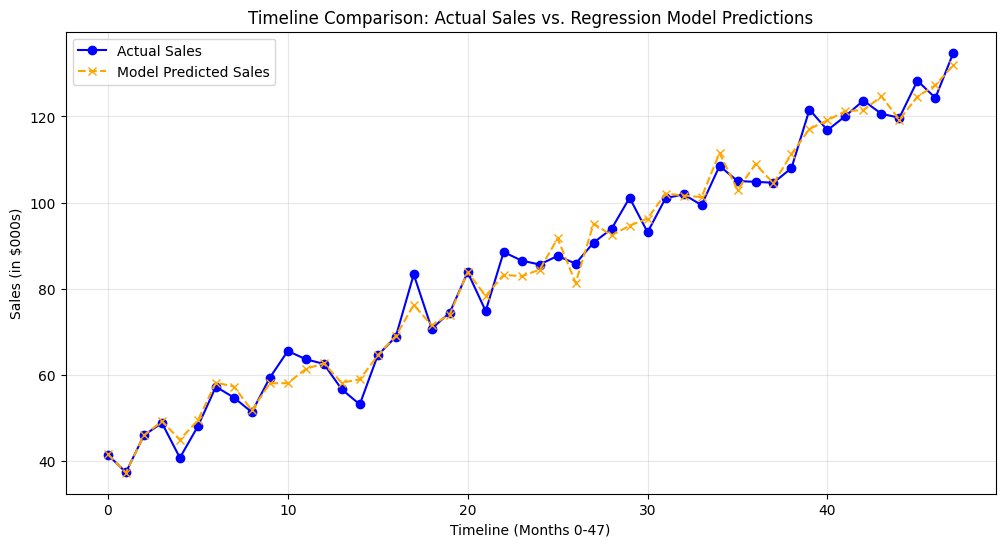

In [8]:
# Step 5: Visualizing Actual vs. Predicted values over time
data['Predicted_Sales'] = model.predict(X_with_constant)

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Total_Product_Sales_USD_k'], label='Actual Sales', color='blue', marker='o')
plt.plot(data.index, data['Predicted_Sales'], label='Model Predicted Sales', color='orange', linestyle='--', marker='x')
plt.title('Timeline Comparison: Actual Sales vs. Regression Model Predictions')
plt.xlabel('Timeline (Months 0-47)')
plt.ylabel('Sales (in $000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()